# Target Creation - Evaluating multi-classes of resolution as Target Variable

## This Notebook Covers
- EDA and distribution of multiple classes in 'Consumer response to consumer'
- Review and understand temporal drift in recent months
- Consolidate the 5 resolution classes to 3 resolution tiers namely 'Closed with explanation', 'Closed with non-monetary relief' and 'Closed with monetary relief'

## Libraries Used
- **Python:** pandas, seaborn, scipy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [4]:
df = pd.read_csv('data/cfpb_complaints_with_nlp_final.csv')
df.head(5)

,Date received,Product,Sub-product,Issue,Sub-issue,Company,State,ZIP code,Submitted via,Company response to consumer,Timely response?,Consumer disputed?,narrative_clean,narrative_for_lda,sentiment_compound,sentiment_neg,sentiment_neu,sentiment_pos,urgency_score,churn_intent,loyalty_score,text_length,word_count,dominant_topic,topic_granular,topic_category,churn_risk_tier
0,01/20/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CA,92345,Web,Closed with non-monetary relief,Yes,NaN,i am writing to have the following information...,writing have the following information removed...,0.9430,0.037,0.794,0.169,0.0,0.4,0.0,662,119,23,T23_credit-report_deleted-credit,Identity Theft / Fraud,Moderate
1,07/03/24,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,Experian Information Solutions Inc.,FL,32824,Web,Closed with non-monetary relief,Yes,NaN,i am a victim of identity theft. please delete...,victim identity theft. please delete remove th...,0.2732,0.100,0.760,0.139,0.0,0.0,0.0,370,68,5,T05_credit-report_credit-reports,Credit Reporting Errors,Minimal
2,09/14/25,Vehicle loan or lease,Loan,Incorrect information on your report,Information belongs to someone else,"SANTANDER HOLDINGS USA, INC.",PA,19143,Web,Closed with explanation,Yes,NaN,"my name is xxxx xxxx, and i am formally disput...","name , and formally disputing fraudulent auto ...",-0.9042,0.151,0.766,0.083,1.0,0.4,0.0,830,140,27,T27_credit-reporting_federal,Credit Reporting Errors,Moderate
3,05/01/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",TX,76105,Web,Closed with non-monetary relief,Yes,NaN,"upon reviewing my credit report, i have identi...","upon reviewing credit report, have identified ...",0.3818,0.000,0.867,0.133,0.0,0.0,0.0,127,18,39,T39_credit-report_inaccurate-accounts,Credit Reporting Errors,Minimal
4,12/08/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,Kubota North America Corporation,MS,391XX,Web,Closed with explanation,Yes,NaN,everything is explained in my resolution packa...,everything explained resolution package ive al...,0.3818,0.000,0.860,0.140,0.0,0.0,0.0,107,17,3,T03_account_bank,Account / Payment Issues,Minimal


In [7]:
df['Date received'] = pd.to_datetime(df['Date received'],format='%m/%d/%y')

In [8]:
df.head(5)

,Date received,Product,Sub-product,Issue,Sub-issue,Company,State,ZIP code,Submitted via,Company response to consumer,Timely response?,Consumer disputed?,narrative_clean,narrative_for_lda,sentiment_compound,sentiment_neg,sentiment_neu,sentiment_pos,urgency_score,churn_intent,loyalty_score,text_length,word_count,dominant_topic,topic_granular,topic_category,churn_risk_tier
0,2025-01-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CA,92345,Web,Closed with non-monetary relief,Yes,NaN,i am writing to have the following information...,writing have the following information removed...,0.9430,0.037,0.794,0.169,0.0,0.4,0.0,662,119,23,T23_credit-report_deleted-credit,Identity Theft / Fraud,Moderate
1,2024-07-03,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,Experian Information Solutions Inc.,FL,32824,Web,Closed with non-monetary relief,Yes,NaN,i am a victim of identity theft. please delete...,victim identity theft. please delete remove th...,0.2732,0.100,0.760,0.139,0.0,0.0,0.0,370,68,5,T05_credit-report_credit-reports,Credit Reporting Errors,Minimal
2,2025-09-14,Vehicle loan or lease,Loan,Incorrect information on your report,Information belongs to someone else,"SANTANDER HOLDINGS USA, INC.",PA,19143,Web,Closed with explanation,Yes,NaN,"my name is xxxx xxxx, and i am formally disput...","name , and formally disputing fraudulent auto ...",-0.9042,0.151,0.766,0.083,1.0,0.4,0.0,830,140,27,T27_credit-reporting_federal,Credit Reporting Errors,Moderate
3,2025-05-01,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",TX,76105,Web,Closed with non-monetary relief,Yes,NaN,"upon reviewing my credit report, i have identi...","upon reviewing credit report, have identified ...",0.3818,0.000,0.867,0.133,0.0,0.0,0.0,127,18,39,T39_credit-report_inaccurate-accounts,Credit Reporting Errors,Minimal
4,2025-12-08,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,Kubota North America Corporation,MS,391XX,Web,Closed with explanation,Yes,NaN,everything is explained in my resolution packa...,everything explained resolution package ive al...,0.3818,0.000,0.860,0.140,0.0,0.0,0.0,107,17,3,T03_account_bank,Account / Payment Issues,Minimal


In [9]:
print("\n" + "="*80)
print("ORIGINAL 5-CLASS DISTRIBUTION")
print("="*80)

# Count and percentages
response_counts = df['Company response to consumer'].value_counts()
response_pct = df['Company response to consumer'].value_counts(normalize=True) * 100

distribution = pd.DataFrame({
    'Count': response_counts,
    'Percentage': response_pct
})

print("\n")
print(distribution)
print(f"\nTotal: {distribution['Count'].sum():,}")


ORIGINAL 5-CLASS DISTRIBUTION


                                  Count  Percentage
Company response to consumer                       
Closed with explanation          844066   60.324124
Closed with non-monetary relief  525819   37.579491
Closed with monetary relief       25380    1.813870
Untimely response                  3068    0.219265
In progress                         885    0.063250

Total: 1,399,218


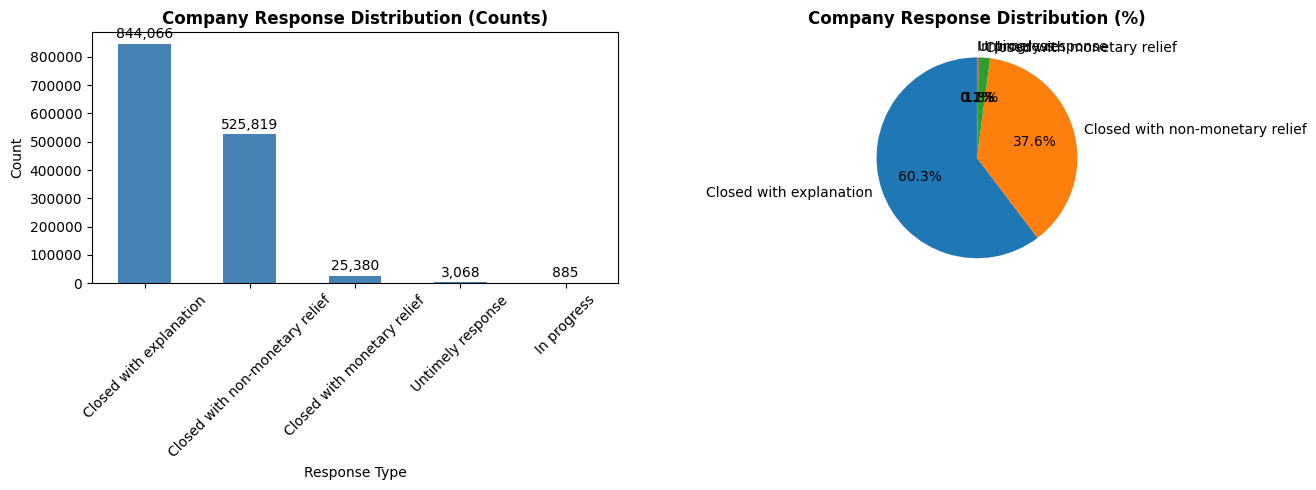

In [10]:
# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
response_counts.plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Company Response Distribution (Counts)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Response Type')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(response_counts):
    ax1.text(i, v + 10000, f'{v:,}', ha='center', va='bottom')

# Pie chart
response_pct.plot(kind='pie', ax=ax2, autopct='%1.1f%%', startangle=90)
ax2.set_title('Company Response Distribution (%)', fontsize=12, fontweight='bold')
ax2.set_ylabel('')

plt.tight_layout()
plt.savefig('outputs/original_5class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
print("\n" + "="*80)
print("CLASS IMBALANCE ANALYSIS")
print("="*80)

# Calculate imbalance ratio
max_class = response_counts.max()
min_class = response_counts.min()
imbalance_ratio = max_class / min_class

print(f"\nLargest class: {response_counts.idxmax()}")
print(f"  Count: {max_class:,} ({response_pct.max():.2f}%)")

print(f"\nSmallest class: {response_counts.idxmin()}")
print(f"  Count: {min_class:,} ({response_pct.min():.2f}%)")

print(f"\nImbalance ratio: {imbalance_ratio:.1f}:1")

if imbalance_ratio > 10:
    print("Severe Imbalance!!")
elif imbalance_ratio > 5:
    print("Moderate Imbalance")
else:
    print("Mild Imbalance")


CLASS IMBALANCE ANALYSIS

Largest class: Closed with explanation
  Count: 844,066 (60.32%)

Smallest class: In progress
  Count: 885 (0.06%)

Imbalance ratio: 953.7:1
Severe Imbalance!!


In [16]:
print("\n" + "="*80)
print("CONSOLIDATING TO 3-TIER FRAMEWORK")
print("="*80)

# Mapping rules
def consolidate_to_tiers(response):
    """
    Consolidate 5 classes into 3 tiers based on service complexity
    
    Tier 0: Explanation Only (low complexity)
    Tier 1: Service Recovery (medium complexity)  
    Tier 2: Compensation (high complexity)
    """
    if pd.isna(response):
        return -1
    
    response_lower = response.lower()
    
    if 'non-monetary relief' in response_lower:
        return 1  # Tier 1: Service Recovery
    
    elif 'monetary relief' in response_lower:
        return 2  # Tier 2: Compensation
    
    elif 'explanation' in response_lower:
        return 0  # Tier 0: Explanation
    
    # Edge cases
    elif 'untimely' in response_lower:
        # Untimely responses likely unresolved - assign to Service Recovery
        return 1
    
    elif 'in progress' in response_lower:
        # In progress - assign to Explanation (low complexity, not yet resolved)
        return 0
    
    else:
        return -1

df['resolution_tier'] = df['Company response to consumer'].apply(consolidate_to_tiers)

unmapped = df[df['resolution_tier'] == -1]
if len(unmapped) > 0:
    print(f"\n {len(unmapped):,} complaints could not be mapped")
    print("Unmapped values:")
    print(unmapped['Company response to consumer'].value_counts())
else:
    print("\nAll complaints successfully mapped to tiers")


CONSOLIDATING TO 3-TIER FRAMEWORK

 4 complaints could not be mapped
Unmapped values:
Series([], Name: count, dtype: int64)


In [17]:
df.head(5)

,Date received,Product,Sub-product,Issue,Sub-issue,Company,State,ZIP code,Submitted via,Company response to consumer,Timely response?,Consumer disputed?,narrative_clean,narrative_for_lda,sentiment_compound,sentiment_neg,sentiment_neu,sentiment_pos,urgency_score,churn_intent,loyalty_score,text_length,word_count,dominant_topic,topic_granular,topic_category,churn_risk_tier,resolution_tier
0,2025-01-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CA,92345,Web,Closed with non-monetary relief,Yes,NaN,i am writing to have the following information...,writing have the following information removed...,0.9430,0.037,0.794,0.169,0.0,0.4,0.0,662,119,23,T23_credit-report_deleted-credit,Identity Theft / Fraud,Moderate,1
1,2024-07-03,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,Experian Information Solutions Inc.,FL,32824,Web,Closed with non-monetary relief,Yes,NaN,i am a victim of identity theft. please delete...,victim identity theft. please delete remove th...,0.2732,0.100,0.760,0.139,0.0,0.0,0.0,370,68,5,T05_credit-report_credit-reports,Credit Reporting Errors,Minimal,1
2,2025-09-14,Vehicle loan or lease,Loan,Incorrect information on your report,Information belongs to someone else,"SANTANDER HOLDINGS USA, INC.",PA,19143,Web,Closed with explanation,Yes,NaN,"my name is xxxx xxxx, and i am formally disput...","name , and formally disputing fraudulent auto ...",-0.9042,0.151,0.766,0.083,1.0,0.4,0.0,830,140,27,T27_credit-reporting_federal,Credit Reporting Errors,Moderate,0
3,2025-05-01,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",TX,76105,Web,Closed with non-monetary relief,Yes,NaN,"upon reviewing my credit report, i have identi...","upon reviewing credit report, have identified ...",0.3818,0.000,0.867,0.133,0.0,0.0,0.0,127,18,39,T39_credit-report_inaccurate-accounts,Credit Reporting Errors,Minimal,1
4,2025-12-08,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,Kubota North America Corporation,MS,391XX,Web,Closed with explanation,Yes,NaN,everything is explained in my resolution packa...,everything explained resolution package ive al...,0.3818,0.000,0.860,0.140,0.0,0.0,0.0,107,17,3,T03_account_bank,Account / Payment Issues,Minimal,0


In [19]:
# Analyze new 3-tier distribution
print("\n" + "-"*80)
print("3-TIER DISTRIBUTION")
print("-"*80)

tier_counts = df[df['resolution_tier'] >= 0]['resolution_tier'].value_counts().sort_index()
tier_pct = df[df['resolution_tier'] >= 0]['resolution_tier'].value_counts(normalize=True).sort_index() * 100

tier_distribution = pd.DataFrame({
    'Tier': ['Tier 0 (Explanation)', 'Tier 1 (Service Recovery)', 'Tier 2 (Compensation)'],
    'Count': tier_counts.values,
    'Percentage': tier_pct.values
})

print("\n")
print(tier_distribution.to_string(index=False))
print(f"\nTotal: {tier_counts.sum():,}")

# Check balance
tier_imbalance = tier_counts.max() / tier_counts.min()
print(f"\nNew imbalance ratio: {tier_imbalance:.1f}:1")

if tier_imbalance < 5:
    print("Mild Imbalance")
elif tier_imbalance < 20:
    print("Visible Imbalance")
elif tier_imbalance < 50:
    print("Moderate Imbalance")
else:
    print("Severe Imbalance!!")


--------------------------------------------------------------------------------
3-TIER DISTRIBUTION
--------------------------------------------------------------------------------


                     Tier  Count  Percentage
     Tier 0 (Explanation) 844951   60.387374
Tier 1 (Service Recovery) 528887   37.798756
    Tier 2 (Compensation)  25380    1.813870

Total: 1,399,218

New imbalance ratio: 33.3:1
Moderate Imbalance


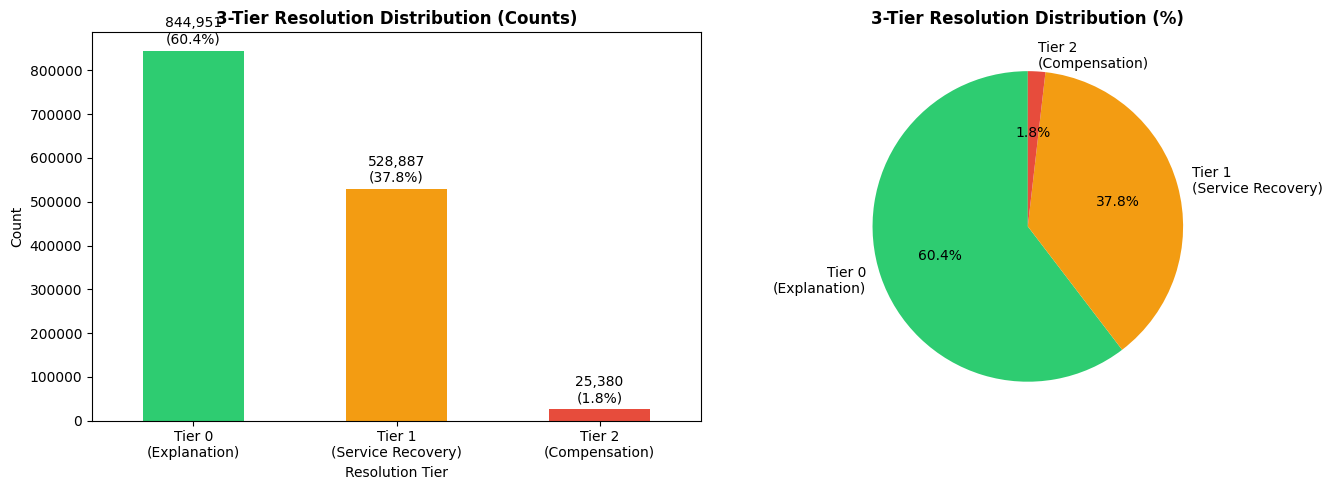

In [20]:
# Visualize 3-tier distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
tier_counts.plot(kind='bar', ax=ax1, color=['#2ecc71', '#f39c12', '#e74c3c'])
ax1.set_title('3-Tier Resolution Distribution (Counts)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Resolution Tier')
ax1.set_ylabel('Count')
ax1.set_xticklabels(['Tier 0\n(Explanation)', 'Tier 1\n(Service Recovery)', 
                     'Tier 2\n(Compensation)'], rotation=0)
for i, v in enumerate(tier_counts):
    ax1.text(i, v + 10000, f'{v:,}\n({tier_pct.iloc[i]:.1f}%)', ha='center', va='bottom')

# Pie chart
tier_pct.plot(kind='pie', ax=ax2, autopct='%1.1f%%', startangle=90,
              colors=['#2ecc71', '#f39c12', '#e74c3c'],
              labels=['Tier 0\n(Explanation)', 'Tier 1\n(Service Recovery)', 
                      'Tier 2\n(Compensation)'])
ax2.set_title('3-Tier Resolution Distribution (%)', fontsize=12, fontweight='bold')
ax2.set_ylabel('')

plt.tight_layout()
plt.savefig('outputs/consolidated_3tier_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
print("\n" + "="*80)
print("TEMPORAL DISTRIBUTION ANALYSIS")
print("="*80)

df['year_month'] = df['Date received'].dt.to_period('M')

monthly_dist = df[df['resolution_tier'] >= 0].groupby('year_month')['resolution_tier'].value_counts(normalize=True).unstack(fill_value=0)

print("\nMonthly tier proportions (last 6 months):")
print(monthly_dist.tail(6))

contingency = pd.crosstab(df[df['resolution_tier'] >= 0]['year_month'], 
                          df[df['resolution_tier'] >= 0]['resolution_tier'])

chi2, p_value, dof, expected = chi2_contingency(contingency)

print(f"\nChi-square test for temporal stability:")
print(f"  Chi2 = {chi2:.2f}, p-value = {p_value:.6f}")

if p_value < 0.001:
    print("Significant temporal variation")
else:
    print("Distribution relatively stable over time")


TEMPORAL DISTRIBUTION ANALYSIS

Monthly tier proportions (last 6 months):
resolution_tier         0         1         2
year_month                                   
2025-08          0.699926  0.287463  0.012611
2025-09          0.684383  0.299108  0.016509
2025-10          0.674334  0.309683  0.015983
2025-11          0.642578  0.340722  0.016700
2025-12          0.610239  0.370245  0.019516
2026-01          0.850709  0.075063  0.074229

Chi-square test for temporal stability:
  Chi2 = 29348.92, p-value = 0.000000
Significant temporal variation


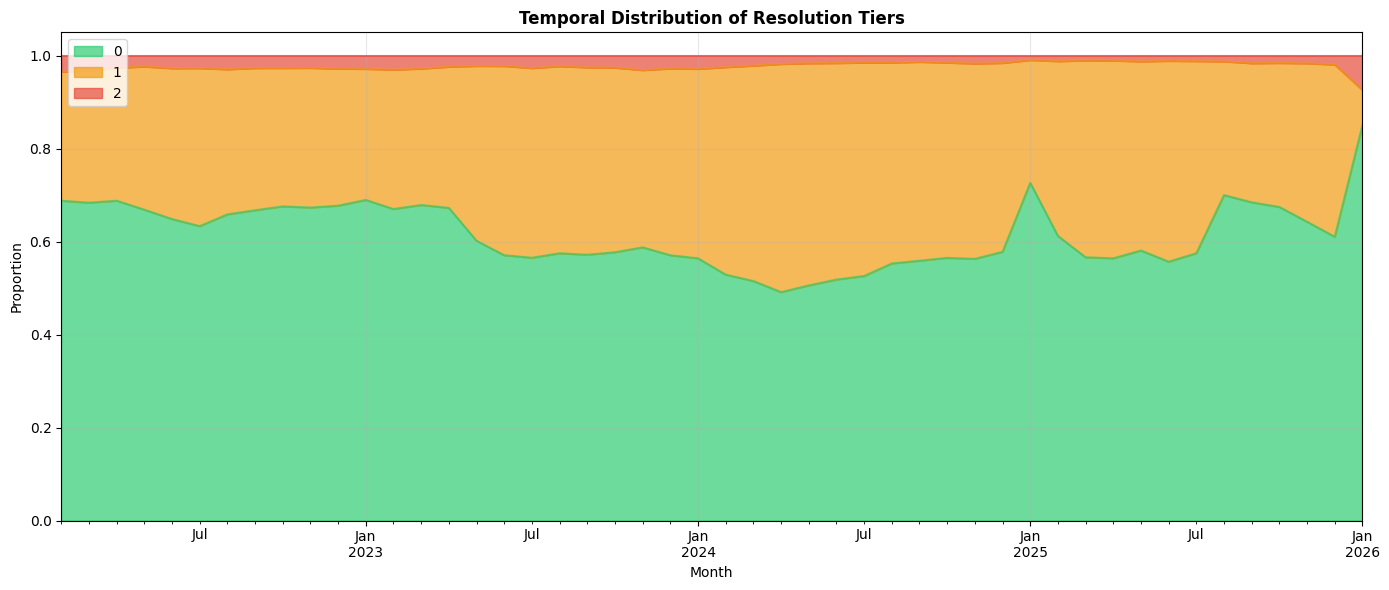

In [23]:
fig, ax = plt.subplots(figsize=(14, 6))

monthly_dist.plot(
    kind='area',
    stacked=True,
    ax=ax,
    alpha=0.7,
    color=['#2ecc71', '#f39c12', '#e74c3c']
)
ax.set_title('Temporal Distribution of Resolution Tiers', fontsize=12, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Proportion')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/temporal_tier_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [24]:
print("\n" + "="*80)
print("TARGET VALIDATION BY TOPIC")
print("="*80)

if 'topic_category' in df.columns:
    topic_tier = df[df['resolution_tier'] >= 0].groupby('topic_category')['resolution_tier'].value_counts(normalize=True).unstack(fill_value=0)
    
    print("\nTier distribution by topic category:")
    print(topic_tier.round(3))
    
    # Statistical test
    contingency_topic = pd.crosstab(df[df['resolution_tier'] >= 0]['topic_category'], 
                                    df[df['resolution_tier'] >= 0]['resolution_tier'])
    
    chi2_topic, p_value_topic, _, _ = chi2_contingency(contingency_topic)
    
    print(f"\nChi-square test (topic vs tier):")
    print(f"  Chi2 = {chi2_topic:.2f}, p-value = {p_value_topic:.6f}")
    
    if p_value_topic < 0.001:
        print("Significant prediction of resolution tier by topic")
    else:
        print("Weak relationship between topics and tiers")
else:
    print("topic_category not found in dataset")


TARGET VALIDATION BY TOPIC

Tier distribution by topic category:
resolution_tier               0      1      2
topic_category                               
Account / Payment Issues  0.719  0.230  0.051
Billing Disputes          0.709  0.101  0.190
Credit Reporting Errors   0.534  0.466  0.000
Debt Collection           0.654  0.345  0.001
General Complaints        0.649  0.345  0.006
Identity Theft / Fraud    0.536  0.458  0.006
Legal / FCRA Violations   0.490  0.510  0.000

Chi-square test (topic vs tier):
  Chi2 = 140460.27, p-value = 0.000000
Significant prediction of resolution tier by topic


In [26]:
df_clean = df[df['resolution_tier'] >= 0].copy(deep=True)
df_clean

,Date received,Product,Sub-product,Issue,Sub-issue,Company,State,ZIP code,Submitted via,Company response to consumer,Timely response?,Consumer disputed?,narrative_clean,narrative_for_lda,sentiment_compound,sentiment_neg,sentiment_neu,sentiment_pos,urgency_score,churn_intent,loyalty_score,text_length,word_count,dominant_topic,topic_granular,topic_category,churn_risk_tier,resolution_tier,year_month
0,2025-01-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CA,92345,Web,Closed with non-monetary relief,Yes,NaN,i am writing to have the following information...,writing have the following information removed...,0.9430,0.037,0.794,0.169,0.0,0.4,0.0,662,119,23,T23_credit-report_deleted-credit,Identity Theft / Fraud,Moderate,1,2025-01
1,2024-07-03,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,Experian Information Solutions Inc.,FL,32824,Web,Closed with non-monetary relief,Yes,NaN,i am a victim of identity theft. please delete...,victim identity theft. please delete remove th...,0.2732,0.100,0.760,0.139,0.0,0.0,0.0,370,68,5,T05_credit-report_credit-reports,Credit Reporting Errors,Minimal,1,2024-07
2,2025-09-14,Vehicle loan or lease,Loan,Incorrect information on your report,Information belongs to someone else,"SANTANDER HOLDINGS USA, INC.",PA,19143,Web,Closed with explanation,Yes,NaN,"my name is xxxx xxxx, and i am formally disput...","name , and formally disputing fraudulent auto ...",-0.9042,0.151,0.766,0.083,1.0,0.4,0.0,830,140,27,T27_credit-reporting_federal,Credit Reporting Errors,Moderate,0,2025-09
3,2025-05-01,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",TX,76105,Web,Closed with non-monetary relief,Yes,NaN,"upon reviewing my credit report, i have identi...","upon reviewing credit report, have identified ...",0.3818,0.000,0.867,0.133,0.0,0.0,0.0,127,18,39,T39_credit-report_inaccurate-accounts,Credit Reporting Errors,Minimal,1,2025-05
4,2025-12-08,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,Kubota North America Corporation,MS,391XX,Web,Closed with explanation,Yes,NaN,everything is explained in my resolution packa...,everything explained resolution package ive al...,0.3818,0.000,0.860,0.140,0.0,0.0,0.0,107,17,3,T03_account_bank,Account / Payment Issues,Minimal,0,2025-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1399217,2024-04-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",FL,33312,Web,Closed with non-monetary relief,Yes,NaN,i am looking to have all items deleted to help...,looking have all items deleted help clear cred...,0.6597,0.088,0.674,0.237,1.0,0.0,0.0,184,34,33,T33_credit-report_credit-bureaus,Identity Theft / Fraud,Minimal,1,2024-04
1399218,2023-12-18,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",TX,78640,Web,Closed with non-monetary relief,Yes,NaN,in accordance with the fair credit reporting a...,accordance with the fair credit reporting act....,-0.5719,0.049,0.918,0.033,0.0,0.0,0.4,1231,223,12,T12_reporting-agency_consumer-reporting,Credit Reporting Errors,Minimal,1,2023-12
1399219,2024-03-06,Credit reporting or other personal consumer re...,Credit reporting,Problem with a company's investigation into an...,Investigation took more than 30 days,Experian Information Solutions Inc.,TX,75217,Web,Closed with explanation,Yes,NaN,i am list

In [27]:
print(f"\nOriginal dataset: {len(df):,} complaints")
print(f"Final dataset: {len(df_clean):,} complaints")
print(f"Removed: {len(df) - len(df_clean):,} complaints ({(len(df) - len(df_clean))/len(df)*100:.2f}%)")

output_path = 'data/cfpb_complaints_target_creation.csv'
df_clean.to_csv(output_path, index=False)

print(f"\nDataset saved to {output_path}")


Original dataset: 1,399,222 complaints
Final dataset: 1,399,218 complaints
Removed: 4 complaints (0.00%)

Dataset saved to data/cfpb_complaints_target_creation.csv
